# Fama-French SMB & HML Factor Replication

This notebook replicates the **SMB** (Small Minus Big) and **HML** (High Minus Low)
factors from:

> Fama, E.F. and French, K.R. (1993), "Common Risk Factors in the Returns on Stocks
> and Bonds", *Journal of Financial Economics*, 33(1), 3-56.

We build the factors from **raw WRDS data** (Compustat, CRSP, and the CCM link table)
and compare our results against the **official Ken French factors** from his data library.

## Why these factors matter

The Fama-French three-factor model extended the CAPM by adding two empirically
motivated risk factors:

- **SMB** captures the *size premium*: historically, small-cap stocks earned higher
  average returns than large-cap stocks.
- **HML** captures the *value premium*: historically, high book-to-market ("value")
  stocks earned higher average returns than low book-to-market ("growth") stocks.

By constructing these factors ourselves, we gain deep understanding of the
methodological choices Fama and French made and why each step matters.

## 0. Configuration

Set your preferences here. You can either:
1. **Query WRDS live** by setting `DATA_SOURCE = 'wrds'` (requires a WRDS account), or
2. **Use local files** by setting `DATA_SOURCE = 'local'` and providing file paths.

The `START_DATE` controls how far back the sample goes. Fama and French (1993) used
data from 1963 onward, but we default to 2000 for faster computation. Change it as needed.

In [2]:
# ── USER CONFIGURATION ──────────────────────────────────────────────

DATA_SOURCE = 'wrds'   # 'wrds' to query live, 'local' to use saved files
START_DATE  = '2000-01-01'  # Change to '1963-07-01' for full FF sample

# If DATA_SOURCE == 'local', set these paths to your saved Parquet/CSV files:
LOCAL_COMPUSTAT_PATH = 'data/compustat_data.csv'
LOCAL_CRSP_PATH      = 'data/crsp_data.csv'
LOCAL_CCM_PATH       = 'data/ccm_data.csv'

# WRDS credentials (only needed if DATA_SOURCE == 'wrds')
# The wrds library will prompt for username/password if not configured.
# Alternatively, set up a ~/.pgpass file per WRDS documentation.
WRDS_USERNAME = None  # e.g. 'your_wrds_id'

# ── END CONFIGURATION ──────────────────────────────────────────────

## 1. Imports

We use standard Python data-science libraries plus `wrds` for database access
and `pandas_datareader` to download official Ken French factors for comparison.

In [3]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from pandas.tseries.offsets import MonthEnd, YearEnd
from scipy import stats
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('All imports successful.')

All imports successful.


## 2. Helper Functions

These three small functions are needed because they are called by pandas
`.apply()` or `.groupby().apply()` later in the pipeline. Everything else
is plain inline code.

In [4]:
def wavg(group, avg_name, weight_name):
    """Value-weighted average — used by groupby().apply() for portfolio returns."""
    d = group[avg_name]
    w = group[weight_name]
    try:
        return (d * w).sum() / w.sum()
    except ZeroDivisionError:
        return np.nan


def sz_bucket(row):
    """Assign 'S' or 'B' based on NYSE median ME — used by .apply()."""
    if pd.isna(row['me']) or pd.isna(row['sizemedn']):
        return ''
    elif row['me'] <= row['sizemedn']:
        return 'S'
    else:
        return 'B'


def bm_bucket(row):
    """Assign 'L', 'M', or 'H' based on NYSE 30/70 B/M breakpoints — used by .apply()."""
    if pd.isna(row['beme']) or pd.isna(row['bm30']) or pd.isna(row['bm70']):
        return ''
    if 0 <= row['beme'] <= row['bm30']:
        return 'L'
    elif row['beme'] <= row['bm70']:
        return 'M'
    elif row['beme'] > row['bm70']:
        return 'H'
    else:
        return ''

print('Helper functions defined.')

Helper functions defined.


## 3. Load Raw Data

We need three raw datasets from WRDS:

| Dataset | WRDS Table | Purpose |
|---------|-----------|--------|
| **Compustat** | `comp.funda` | Annual accounting data (book equity) |
| **CRSP** | `crsp.msf`, `crsp.msenames`, `crsp.msedelist` | Monthly stock returns, exchange codes, delisting returns |
| **CCM** | `crsp.ccmxpf_linktable` | Links Compustat GVKEYs to CRSP PERMNOs |

### Why do we need all three?

- **Compustat** gives us book equity (the numerator of B/M).
- **CRSP** gives us stock prices, returns, and shares outstanding - needed for
  market equity (the denominator of B/M) and for computing portfolio returns.
- **CCM link table** maps between the two databases. Compustat identifies firms
  by `gvkey`; CRSP identifies securities by `permno`. The link table provides the
  bridge, including the date range over which each link is valid.

In [5]:
if DATA_SOURCE == 'wrds':
    import wrds
    conn = wrds.Connection(wrds_username=WRDS_USERNAME) if WRDS_USERNAME else wrds.Connection()

    # ── Compustat ──
    comp = conn.raw_sql(f"""
        SELECT gvkey, datadate, at, pstkl, txditc, pstkrv, seq, pstk
        FROM comp.funda
        WHERE indfmt='INDL'
          AND datafmt='STD'
          AND popsrc='D'
          AND consol='C'
          AND datadate >= '{START_DATE}'
    """, date_cols=['datadate'])

    # ── CRSP monthly stock file + name history ──
    crsp_m = conn.raw_sql(f"""
        SELECT a.permno, a.permco, a.date, b.shrcd, b.exchcd,
               a.ret, a.retx, a.shrout, a.prc
        FROM crsp.msf AS a
        LEFT JOIN crsp.msenames AS b
          ON a.permno = b.permno
         AND b.namedt <= a.date
         AND a.date <= b.nameendt
        WHERE a.date > '{START_DATE}'
          AND b.exchcd BETWEEN 1 AND 3
    """, date_cols=['date'])

    # ── CRSP delisting returns ──
    dlret = conn.raw_sql("""
        SELECT permno, dlret, dlstdt
        FROM crsp.msedelist
    """, date_cols=['dlstdt'])

    # ── CCM link table ──
    ccm = conn.raw_sql("""
        SELECT gvkey, lpermno AS permno, linktype, linkprim,
               linkdt, linkenddt
        FROM crsp.ccmxpf_linktable
        WHERE SUBSTR(linktype,1,1) = 'L'
          AND (linkprim = 'C' OR linkprim = 'P')
    """, date_cols=['linkdt', 'linkenddt'])

    conn.close()
    print(f'Loaded from WRDS: comp={len(comp)}, crsp_m={len(crsp_m)}, dlret={len(dlret)}, ccm={len(ccm)}')

elif DATA_SOURCE == 'local':
    def _load(path):
        if path.endswith('.parquet'):
            return pd.read_parquet(path)
        else:
            return pd.read_csv(path, parse_dates=True)

    comp   = _load(LOCAL_COMPUSTAT_PATH)
    crsp_m = _load(LOCAL_CRSP_PATH)

    # Local CRSP file may already include dlret merged, or separate
    ccm = _load(LOCAL_CCM_PATH)

    # Delisting returns: check if already merged into crsp_m
    if 'dlret' not in crsp_m.columns:
        raise ValueError(
            'Local crsp_data must include dlret column, '
            'or provide a separate delisting file.'
        )
    dlret = pd.DataFrame()  # placeholder, already in crsp_m
    print(f'Loaded from local files: comp={len(comp)}, crsp_m={len(crsp_m)}, ccm={len(ccm)}')

else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE}. Use 'wrds' or 'local'.")

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Loaded from WRDS: comp=300444, crsp_m=1914417, dlret=38843, ccm=40884


In [6]:
import os

if DATA_SOURCE == 'wrds':
    os.makedirs('data', exist_ok=True)
    comp.to_csv('data/compustat_data.csv', index=False)
    crsp_m.to_csv('data/crsp_data.csv', index=False)
    dlret.to_csv('data/dlret_data.csv', index=False)
    ccm.to_csv('data/ccm_data.csv', index=False)
    print('✓ Data saved to data/ folder')

✓ Data saved to data/ folder


## 4. Compustat Block: Book Equity Construction

### What is book equity?

Book equity (BE) is the accounting value of shareholders' claim on the firm.
Fama and French (1993) define it as:

$$
BE = \text{Stockholders' Equity (SEQ)} + \text{Deferred Taxes (TXDITC)} - \text{Preferred Stock (PS)}
$$

### Preferred stock fallback hierarchy

Compustat reports preferred stock in three ways. Fama and French use this
priority order:

1. **Redemption value** (`pstkrv`) — what the firm would pay to retire preferred shares
2. **Liquidating value** (`pstkl`) — what preferred holders get in liquidation
3. **Par value** (`pstk`) — the nominal face value

If all are missing, preferred stock is set to zero.

### Why keep only positive book equity?

A negative book equity means liabilities exceed assets — such firms have no
meaningful book-to-market ratio, so they're excluded from the B/M sort.

### Compustat history count

We count how many years each firm has appeared in Compustat. Fama and French
require at least **two years** of Compustat data before a firm enters portfolios,
to reduce the impact of backfill bias (Compustat historically added firms with
retroactive data).

In [7]:
# ── Compustat: build book equity ─────────────────────────────────
comp['year'] = comp['datadate'].dt.year

# Preferred stock fallback: pstkrv → pstkl → pstk → 0
comp['ps'] = np.where(comp['pstkrv'].isnull(), comp['pstkl'], comp['pstkrv'])
comp['ps'] = np.where(comp['ps'].isnull(), comp['pstk'], comp['ps'])
comp['ps'] = np.where(comp['ps'].isnull(), 0, comp['ps'])
comp['txditc'] = comp['txditc'].fillna(0)

# Book equity = stockholders' equity + deferred taxes − preferred stock
comp['be'] = (comp['seq'] + comp['txditc'] - comp['ps']).astype(float)
comp['be'] = np.where(comp['be'] > 0, comp['be'], np.nan)  # keep positive BE only

# Count years in Compustat (for backfill-bias filter)
comp = comp.sort_values(by=['gvkey', 'datadate'])
comp['count'] = comp.groupby(['gvkey']).cumcount()

comp = comp[['gvkey', 'datadate', 'year', 'be', 'count']]

print(f'Compustat after BE construction: {len(comp)} firm-years')
print(f'Positive BE: {comp["be"].notna().sum()} | Missing/negative BE: {comp["be"].isna().sum()}')
comp.head(10)

Compustat after BE construction: 300444 firm-years
Positive BE: 199529 | Missing/negative BE: 100915


/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/633876418.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  comp['year'] = comp['datadate'].dt.year
/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/633876418

,gvkey,datadate,year,be,count
0,001004,2000-05-31,2000,395.535,0
1,001004,2001-05-31,2001,395.275,1
2,001004,2002-05-31,2002,340.836,2
3,001004,2003-05-31,2003,317.589,3
4,001004,2004-05-31,2004,319.312,4
5,001004,2005-05-31,2005,332.833,5
6,001004,2006-05-31,2006,448.074,6
7,001004,2007-05-31,2007,534.364,7
8,001004,2008-05-31,2008,613.266,8
9,001004,2009-05-31,2009,697.158,9


## 5. CRSP Block: Returns, Market Equity, and Delisting Adjustment

### Why delisting returns matter

When a stock is **delisted** (e.g., bankruptcy, merger, regulatory action), CRSP
records the final return in a separate delisting file (`crsp.msedelist`). If we
ignore this, we create **survivorship bias** — we'd miss catastrophic losses from
bankrupt firms, making average returns look better than they actually were.

The adjusted return is:

$$
r_{\text{adj}} = (1 + r_{\text{ret}}) \times (1 + r_{\text{delist}}) - 1
$$

### Market equity

$$
ME = |\text{Price}| \times \text{Shares Outstanding}
$$

We take the absolute value of price because CRSP uses negative prices to
indicate bid/ask midpoints when closing prices are unavailable.

### Why permco-level aggregation matters

A single company (`permco`) can have multiple share classes, each with its own
`permno`. To get the **total** market cap of the firm, we must sum ME across
all `permno`s belonging to the same `permco`. We then assign this total ME to
the `permno` with the largest individual ME (the primary trading vehicle).

### December market equity

The book-to-market ratio uses **December** ME as the denominator. Why December?
Fama and French want the market value to be **known before** portfolios are
formed in June. Since most firms have fiscal year ends in December, the
December ME is the most recent figure that aligns with the annual book value.
Using the December ME of year $t-1$ with portfolios formed in June of year $t$
ensures a **6-month gap** that prevents look-ahead bias.

### July-to-June weight logic

Fama and French form portfolios at the end of June each year and hold them
for 12 months (July through June). The **weight** for value-weighted returns
must track each stock's evolving market cap through the year. The `mebase`
is the stock's ME at the start of the holding period, and `cumretx`
(cumulative ex-dividend return) scales it forward month by month.

In [8]:
# ── CRSP: format columns ────────────────────────────────────────
crsp_m[['permco', 'permno', 'shrcd', 'exchcd']] = (
    crsp_m[['permco', 'permno', 'shrcd', 'exchcd']].astype(int)
)
crsp_m['jdate'] = crsp_m['date'] + MonthEnd(0)

print(f'CRSP monthly records: {len(crsp_m)}')

CRSP monthly records: 1914417


/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/1461587024.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  crsp_m['jdate'] = crsp_m['date'] + MonthEnd(0)


### 5a. Merge Delisting Returns

In [9]:
# ── Merge delisting returns ─────────────────────────────────────
if len(dlret) > 0:  # If from WRDS (local files may already have dlret)
    dlret['permno'] = dlret['permno'].astype(int)
    dlret['jdate'] = dlret['dlstdt'] + MonthEnd(0)
    crsp = pd.merge(crsp_m, dlret[['permno', 'dlret', 'jdate']],
                    how='left', on=['permno', 'jdate'])
else:
    crsp = crsp_m.copy()

crsp['dlret'] = crsp['dlret'].fillna(0)
crsp['ret'] = crsp['ret'].fillna(0)
crsp['retadj'] = (1 + crsp['ret']) * (1 + crsp['dlret']) - 1

# Market equity
crsp['me'] = crsp['prc'].abs() * crsp['shrout']
crsp = crsp.drop(['dlret', 'prc', 'shrout'], axis=1, errors='ignore')
crsp = crsp.sort_values(by=['jdate', 'permco', 'me'])

print(f'CRSP after delisting merge: {len(crsp)} records')
print(f'Non-zero delisting adjustments: {(crsp["retadj"] != crsp["ret"]).sum()}')

/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/3411167973.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dlret['permno'] = dlret['permno'].astype(int)
/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/34

CRSP after delisting merge: 1914417 records
Non-zero delisting adjustments: 1680153


### 5b. Aggregate Market Equity at permco Level

In [10]:
# ── Permco-level aggregation ────────────────────────────────────
# Sum of ME across all permno within each permco/date
crsp_summe = crsp.groupby(['jdate', 'permco'])['me'].sum().reset_index()
# Largest ME within each permco/date (to find primary permno)
crsp_maxme = crsp.groupby(['jdate', 'permco'])['me'].max().reset_index()

# Keep the permno with the largest individual ME
crsp1 = pd.merge(crsp, crsp_maxme, how='inner', on=['jdate', 'permco', 'me'])
crsp1 = crsp1.drop(['me'], axis=1)

# Replace with total permco-level ME
crsp2 = pd.merge(crsp1, crsp_summe, how='inner', on=['jdate', 'permco'])
crsp2 = crsp2.sort_values(by=['permno', 'jdate']).drop_duplicates()

print(f'CRSP after permco aggregation: {len(crsp2)} records')

CRSP after permco aggregation: 1828744 records


### 5c. December Market Equity and July-to-June Weights

In [11]:
# ── December ME ─────────────────────────────────────────────────
crsp2['year'] = crsp2['jdate'].dt.year
crsp2['month'] = crsp2['jdate'].dt.month

decme = crsp2[crsp2['month'] == 12].copy()
decme = decme[['permno', 'date', 'jdate', 'me', 'year']].rename(columns={'me': 'dec_me'})

# ── July-to-June calendar ───────────────────────────────────────
crsp2['ffdate'] = crsp2['jdate'] + MonthEnd(-6)
crsp2['ffyear'] = crsp2['ffdate'].dt.year
crsp2['ffmonth'] = crsp2['ffdate'].dt.month
crsp2['1+retx'] = 1 + crsp2['retx']
crsp2 = crsp2.sort_values(by=['permno', 'date'])

# Cumulative ex-dividend return within each July-June period
crsp2['cumretx'] = crsp2.groupby(['permno', 'ffyear'])['1+retx'].cumprod()
crsp2['lcumretx'] = crsp2.groupby(['permno'])['cumretx'].shift(1)

# Lagged ME
crsp2['lme'] = crsp2.groupby(['permno'])['me'].shift(1)
crsp2['count'] = crsp2.groupby(['permno']).cumcount()
crsp2['lme'] = np.where(crsp2['count'] == 0, crsp2['me'] / crsp2['1+retx'], crsp2['lme'])

# Baseline ME (start of each July-June period)
mebase = crsp2[crsp2['ffmonth'] == 1][['permno', 'ffyear', 'lme']].rename(
    columns={'lme': 'mebase'}
)
crsp3 = pd.merge(crsp2, mebase, how='left', on=['permno', 'ffyear'])
crsp3['wt'] = np.where(
    crsp3['ffmonth'] == 1,
    crsp3['lme'],
    crsp3['mebase'] * crsp3['lcumretx']
)

# Shift Dec ME forward by one year (Dec year t-1 used for June year t sorts)
decme['year'] = decme['year'] + 1
decme = decme[['permno', 'year', 'dec_me']]

print(f'CRSP with weights: {len(crsp3)} records')

/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/3463782818.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  crsp2['year'] = crsp2['jdate'].dt.year
/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/346378281

CRSP with weights: 1828744 records


/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/3463782818.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  crsp2['cumretx'] = crsp2.groupby(['permno', 'ffyear'])['1+retx'].cumprod()
/var/folders/bj/kf7364qd75l3zs_291gg0

### 5d. June Snapshot

We take a snapshot of each stock's characteristics as of **June** each year.
This is the point at which portfolios are formed. The June ME is used for the
size sort, and Dec ME of the prior year is used for the B/M sort.

In [12]:
# ── June snapshot ───────────────────────────────────────────────
crsp3_jun = crsp3[crsp3['month'] == 6]
crsp_jun = pd.merge(crsp3_jun, decme, how='inner', on=['permno', 'year'])
crsp_jun = crsp_jun[[
    'permno', 'date', 'jdate', 'shrcd', 'exchcd',
    'retadj', 'me', 'wt', 'cumretx', 'mebase', 'lme', 'dec_me'
]]
crsp_jun = crsp_jun.sort_values(by=['permno', 'jdate']).drop_duplicates()

print(f'June snapshots: {len(crsp_jun)} stock-years')

June snapshots: 139751 stock-years


## 6. CCM Block: Linking Compustat to CRSP

### Why is the CCM link table needed?

Compustat and CRSP are maintained by different organizations and use different
identifiers:
- Compustat uses **GVKEY** (a firm-level identifier)
- CRSP uses **PERMNO** (a security-level identifier)

The CRSP-Compustat Merged (CCM) link table provides the mapping between these
identifiers, along with the **date range** during which each link is valid.

We only use links where:
- `linktype` starts with 'L' (primary link types)
- `linkprim` is 'C' or 'P' (primary security link)

### June `jdate` for merging

We create a June `jdate` from each Compustat fiscal-year-end date:
1. Round `datadate` up to the calendar year end -> `yearend`
2. Add 6 months -> `jdate` (the June when this data would be used)

This ensures that fiscal-year data is only used **after** it would have been
publicly available.

### Book-to-market ratio

$$
B/M = \frac{BE \times 1000}{\text{Dec ME}}
$$

The factor of 1000 adjusts for Compustat reporting in millions vs. CRSP
reporting in thousands.

In [13]:
# ── CCM: link Compustat to CRSP ─────────────────────────────────
ccm['linkenddt'] = ccm['linkenddt'].fillna(pd.to_datetime('today'))

ccm1 = pd.merge(
    comp[['gvkey', 'datadate', 'be', 'count']],
    ccm,
    how='left',
    on=['gvkey']
)

ccm1['yearend'] = ccm1['datadate'] + YearEnd(0)
ccm1['jdate'] = ccm1['yearend'] + MonthEnd(6)

# Keep only links valid at the June formation date
ccm2 = ccm1[(ccm1['jdate'] >= ccm1['linkdt']) & (ccm1['jdate'] <= ccm1['linkenddt'])]
ccm2 = ccm2[['gvkey', 'permno', 'datadate', 'yearend', 'jdate', 'be', 'count']]

# Merge with June CRSP data
ccm_jun = pd.merge(crsp_jun, ccm2, how='inner', on=['permno', 'jdate'])
ccm_jun['beme'] = ccm_jun['be'] * 1000 / ccm_jun['dec_me']

print(f'CCM merged June records: {len(ccm_jun)}')
ccm_jun[['permno', 'jdate', 'me', 'be', 'dec_me', 'beme']].head(10)

/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/4262962166.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ccm['linkenddt'] = ccm['linkenddt'].fillna(pd.to_datetime('today'))
/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000g

CCM merged June records: 137265


/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/4262962166.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ccm_jun['beme'] = ccm_jun['be'] * 1000 / ccm_jun['dec_me']


,permno,jdate,me,be,dec_me,beme
0,10001,2001-06-30,29653.4,18.079,24355.5,0.742296
1,10001,2002-06-30,25019.28,19.846,29380.7,0.675477
2,10001,2003-06-30,15595.95,20.691,19046.441,1.086345
3,10001,2004-06-30,17309.34,21.113,15446.2,1.366873
4,10001,2005-06-30,26362.65,18.264,17933.1,1.018452
5,10001,2006-06-30,26464.68,23.768,28421.0,0.836283
6,10001,2007-06-30,42885.0,25.293,32844.9,0.770074
7,10001,2008-06-30,46751.75,27.152,40652.5,0.667905
8,10001,2009-06-30,36988.1699,30.322,35493.22,0.854304
9,10001,2010-06-30,66028.8,35.907,44918.3,0.799385


## 7. NYSE Breakpoints

### Why NYSE-only breakpoints?

Fama and French (1993) compute size and B/M breakpoints using **only NYSE stocks**.
This is a critical design choice:

- NASDAQ and AMEX have many more small, speculative firms than NYSE.
- If we used all exchanges, the size median would be dragged down, putting
  the vast majority of firms into the "Big" category.
- Using NYSE-only breakpoints ensures the **Big** and **Small** groups are
  economically meaningful: the median NYSE firm is genuinely mid-sized.

### Breakpoint definitions

- **Size**: NYSE median ME -> stocks below are "Small", above are "Big"
- **B/M**: NYSE 30th and 70th percentiles -> creates three groups:
  - **Low (Growth)**: B/M <= 30th percentile
  - **Medium**: 30th < B/M <= 70th percentile
  - **High (Value)**: B/M > 70th percentile

### Why June sorts?

Portfolios are formed at the **end of June** each year. This gives a 6-month
gap between the fiscal year end (typically December) and portfolio formation.
The gap ensures that annual accounting data (book equity) would have been
publicly available by the time investors sort stocks - avoiding **look-ahead bias**.

### Filter criteria

Following FF (1993), we require:
- NYSE stocks only (`exchcd == 1`)
- Positive book-to-market (`beme > 0`)
- Positive market equity (`me > 0`)
- At least 2 years of Compustat data (`count >= 1`, since count is 0-indexed)
- Ordinary common shares only (`shrcd` in 10, 11)

In [14]:
# ── NYSE breakpoints ────────────────────────────────────────────
nyse = ccm_jun[
    (ccm_jun['exchcd'] == 1) &
    (ccm_jun['beme'] > 0) &
    (ccm_jun['me'] > 0) &
    (ccm_jun['count'] >= 1) &
    ((ccm_jun['shrcd'] == 10) | (ccm_jun['shrcd'] == 11))
]

# Size: NYSE median ME
nyse_sz = nyse.groupby(['jdate'])['me'].median().to_frame().reset_index().rename(
    columns={'me': 'sizemedn'}
)

# B/M: NYSE 30th and 70th percentiles
nyse_bm = nyse.groupby(['jdate'])['beme'].describe(percentiles=[0.3, 0.7]).reset_index()
nyse_bm = nyse_bm[['jdate', '30%', '70%']].rename(columns={'30%': 'bm30', '70%': 'bm70'})

nyse_breaks = pd.merge(nyse_sz, nyse_bm, how='inner', on=['jdate'])

print(f'NYSE breakpoints computed for {len(nyse_breaks)} June dates')
nyse_breaks.head()

NYSE breakpoints computed for 24 June dates


,jdate,sizemedn,bm30,bm70
0,2001-06-30,511996.625,0.517587,0.832615
1,2002-06-30,1248211.62,0.396231,0.846887
2,2003-06-30,1197563.76,0.467362,0.918064
3,2004-06-30,1702667.065,0.375018,0.703349
4,2005-06-30,1855586.955,0.356096,0.63635


## 8. Assign June Portfolios

Each stock is placed into one of **six portfolios** based on the intersection
of the 2 size groups x 3 B/M groups:

|  | Low B/M (Growth) | Medium B/M | High B/M (Value) |
|--|-------------------|------------|-------------------|
| **Small** | SL | SM | SH |
| **Big** | BL | BM | BH |

These portfolio assignments are made in **June** and held for the following
12 months (July through June of the next year).

In [15]:
# ── Assign portfolios ───────────────────────────────────────────
ccm1_jun = pd.merge(ccm_jun, nyse_breaks, how='left', on=['jdate'])

# Ensure numeric types
cols = ['beme', 'me', 'count']
ccm1_jun[cols] = ccm1_jun[cols].astype('float')

# Filter mask: positive B/M, positive ME, enough Compustat history
mask = (
    (ccm1_jun['beme'] > 0) &
    (ccm1_jun['me'] > 0) &
    (ccm1_jun['count'] >= 1)
)

ccm1_jun['szport'] = ''
ccm1_jun['bmport'] = ''
ccm1_jun.loc[mask, 'szport'] = ccm1_jun.loc[mask].apply(sz_bucket, axis=1)
ccm1_jun.loc[mask, 'bmport'] = ccm1_jun.loc[mask].apply(bm_bucket, axis=1)

ccm1_jun['posbm'] = np.where(mask, 1, 0)
ccm1_jun['nonmissport'] = np.where(ccm1_jun['bmport'] != '', 1, 0)

# Store June portfolio assignments
june = ccm1_jun[['permno', 'date', 'jdate', 'bmport', 'szport', 'posbm', 'nonmissport']].copy()
june['ffyear'] = june['jdate'].dt.year

print(f'Portfolio assignments: {len(june)} stock-years')
print(june.groupby(['szport', 'bmport']).size().unstack(fill_value=0))

/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/1153761802.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ccm1_jun['szport'] = ''
/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/1153761802.py:16: Futur

Portfolio assignments: 137265 stock-years
bmport             H      L      M
szport                            
        25552      0      0      0
B           0   5645  11142   9747
S           0  36161  20721  28297


/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/1153761802.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ccm1_jun['nonmissport'] = np.where(ccm1_jun['bmport'] != '', 1, 0)
/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000g

## 9. Merge Assignments to Monthly Returns

We merge the June portfolio labels back into the full monthly CRSP dataset.
Each stock keeps its June assignment for the 12 months from July of year $t$
through June of year $t+1$. This is achieved by matching on `permno` and `ffyear`.

In [16]:
# ── Merge June assignments to monthly returns ───────────────────
crsp3_cols = ['date', 'permno', 'shrcd', 'exchcd', 'retadj', 'me', 'wt',
              'cumretx', 'ffyear', 'jdate']
crsp3_sub = crsp3[crsp3_cols]

ccm3 = pd.merge(
    crsp3_sub,
    june[['permno', 'ffyear', 'szport', 'bmport', 'posbm', 'nonmissport']],
    how='left',
    on=['permno', 'ffyear']
)

# Keep only valid portfolio members
ccm4 = ccm3[
    (ccm3['wt'] > 0) &
    (ccm3['posbm'] == 1) &
    (ccm3['nonmissport'] == 1) &
    ((ccm3['shrcd'] == 10) | (ccm3['shrcd'] == 11))
]

print(f'Monthly records for portfolio returns: {len(ccm4)}')

Monthly records for portfolio returns: 974834


## 10. Compute Value-Weighted Portfolio Returns

### Why value weighting?

Fama and French (1993) use **value-weighted** returns for their factor portfolios.
Value weighting means each stock's return is weighted by its market cap. This
ensures:

1. The portfolio reflects the **investable opportunity set** — you could actually
   hold this portfolio in practice.
2. Tiny illiquid stocks don't dominate the returns (as they would with equal weighting).
3. The factors capture economically meaningful size and value premiums.

In [17]:
# ── Value-weighted portfolio returns ─────────────────────────────
vwret = ccm4.groupby(['jdate', 'szport', 'bmport']).apply(
    wavg, 'retadj', 'wt', include_groups=False
).to_frame().reset_index().rename(columns={0: 'vwret'})
vwret['sbport'] = vwret['szport'] + vwret['bmport']

# Firm counts per portfolio
vwret_n = ccm4.groupby(['jdate', 'szport', 'bmport'])['retadj'].count().reset_index().rename(
    columns={'retadj': 'n_firms'}
)
vwret_n['sbport'] = vwret_n['szport'] + vwret_n['bmport']

# Pivot to wide format
ff_factors = vwret.pivot(index='jdate', columns='sbport', values='vwret').reset_index()
ff_nfirms = vwret_n.pivot(index='jdate', columns='sbport', values='n_firms').reset_index()

print(f'Portfolio returns computed for {len(ff_factors)} months')
ff_factors.head()

Portfolio returns computed for 282 months


/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/430852904.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  vwret['sbport'] = vwret['szport'] + vwret['bmport']
/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_243

sbport,jdate,BH,BL,BM,SH,SL,SM
0,2001-07-31,NaN,-0.047183,0.004105,-0.116798,0.055752,-0.424441
1,2001-08-31,NaN,-0.269278,-0.146202,0.012570,-0.079821,-0.073748
2,2001-09-30,NaN,-0.335469,-0.190479,-0.072214,-0.294401,-0.215452
3,2001-10-31,NaN,0.028412,0.076612,0.061333,0.049690,-0.134346
4,2001-11-30,NaN,0.368032,-0.007266,0.019214,0.000041,-0.297152


## 11. Construct SMB and HML

The Fama-French factors are built from the 2x3 portfolios:

$$
\text{SMB} = \frac{SL + SM + SH}{3} - \frac{BL + BM + BH}{3}
$$

$$
\text{HML} = \frac{SH + BH}{2} - \frac{SL + BL}{2}
$$

- **SMB** (Small Minus Big) averages across B/M groups to isolate the size effect.
- **HML** (High Minus Low) averages across size groups to isolate the value effect.

In [18]:
# ── Construct SMB and HML ────────────────────────────────────────
ff_factors['WSMB'] = (ff_factors['SL'] + ff_factors['SM'] + ff_factors['SH']) / 3 \
                   - (ff_factors['BL'] + ff_factors['BM'] + ff_factors['BH']) / 3
ff_factors['WHML'] = (ff_factors['SH'] + ff_factors['BH']) / 2 \
                   - (ff_factors['SL'] + ff_factors['BL']) / 2
ff_factors = ff_factors.rename(columns={'jdate': 'date'})

# Firm counts
ff_nfirms['TOTAL'] = (
    ff_nfirms['SL'] + ff_nfirms['SM'] + ff_nfirms['SH'] +
    ff_nfirms['BL'] + ff_nfirms['BM'] + ff_nfirms['BH']
)
ff_nfirms = ff_nfirms.rename(columns={'jdate': 'date'})

print('Our constructed factors (first 10 months):')
ff_factors[['date', 'WSMB', 'WHML']].head(10)

Our constructed factors (first 10 months):


/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/1093362987.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ff_factors['WSMB'] = (ff_factors['SL'] + ff_factors['SM'] + ff_factors['SH']) / 3 \
/var/folders/bj/kf7364qd75l3z

sbport,date,WSMB,WHML
0,2001-07-31,NaN,NaN
1,2001-08-31,NaN,NaN
2,2001-09-30,NaN,NaN
3,2001-10-31,NaN,NaN
4,2001-11-30,NaN,NaN
5,2001-12-31,NaN,NaN
6,2002-01-31,NaN,NaN
7,2002-02-28,NaN,NaN
8,2002-03-31,NaN,NaN
9,2002-04-30,NaN,NaN


## 12. Compare with Official Ken French Factors

We download the official Fama-French three-factor data from
[Ken French's Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)
and compare our SMB and HML against the official series.

We use `pandas_datareader` to fetch the data automatically.

In [19]:
# ── Download official Ken French factors ────────────────────────
try:
    import pandas_datareader.data as web
    ff_official = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=START_DATE)[0]
except ImportError:
    print('pandas_datareader not installed. Installing...')
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas-datareader', '-q'])
    import pandas_datareader.data as web
    ff_official = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=START_DATE)[0]

# Ken French data is in percentage points -> convert to decimal
ff_official = ff_official / 100.0
ff_official.index = ff_official.index.to_timestamp() + MonthEnd(0)
ff_official = ff_official.reset_index().rename(columns={'index': 'date', 'Date': 'date'})
# Handle potential column name variations
if 'date' not in ff_official.columns:
    ff_official = ff_official.rename(columns={ff_official.columns[0]: 'date'})

print(f'Official FF factors: {len(ff_official)} months')
print(f'Date range: {ff_official["date"].min()} to {ff_official["date"].max()}')
ff_official.head()

Official FF factors: 314 months
Date range: 2000-01-31 00:00:00 to 2026-02-28 00:00:00


/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/1427162026.py:4: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_official = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=START_DATE)[0]
/var/folders/bj/kf7364qd75l3zs_291gg0ljh0000gn/T/ipykernel_24391/1427162026.py:4: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_official = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=START_DATE)[0]


,date,Mkt-RF,SMB,HML,RF
0,2000-01-31,-0.0474,0.0516,-0.0112,0.0041
1,2000-02-29,0.0246,0.2125,-0.0977,0.0043
2,2000-03-31,0.0521,-0.1741,0.0850,0.0047
3,2000-04-30,-0.0639,-0.0600,0.0645,0.0046
4,2000-05-31,-0.0439,-0.0608,0.0459,0.0050


In [20]:
# ── Merge our factors with official ─────────────────────────────
ff_comp = pd.merge(
    ff_factors[['date', 'WSMB', 'WHML']].rename(columns={'WSMB': 'Our SMB', 'WHML': 'Our HML'}),
    ff_official[['date', 'SMB', 'HML']].rename(columns={'SMB': 'FF SMB', 'HML': 'FF HML'}),
    how='inner',
    on='date'
)

print(f'Comparison sample: {len(ff_comp)} overlapping months')
print(f'Date range: {ff_comp["date"].min()} to {ff_comp["date"].max()}')
ff_comp.head()

Comparison sample: 282 overlapping months
Date range: 2001-07-31 00:00:00 to 2024-12-31 00:00:00


,date,Our SMB,Our HML,FF SMB,FF HML
0,2001-07-31,NaN,NaN,-0.0405,0.0495
1,2001-08-31,NaN,NaN,0.0219,0.0286
2,2001-09-30,NaN,NaN,-0.0623,0.0152
3,2001-10-31,NaN,NaN,0.0749,-0.0731
4,2001-11-30,NaN,NaN,-0.0057,0.0217


## 13. Statistical Comparison

We evaluate our replication quality using:

1. **Pearson correlation** — measures linear co-movement
2. **OLS regression (beta & R-squared)** — measures how closely our factor tracks the official one
3. **Cointegration test** — tests whether the two series share a long-run equilibrium

A good replication should have:
- Correlation > 0.95
- Beta close to 1.0
- R-squared > 0.90
- Cointegration p-value < 0.05

In [21]:
# ── SMB comparison ───────────────────────────────────────────────
_df = ff_comp[['Our SMB', 'FF SMB']].dropna()
smb_corr, smb_corr_p = stats.pearsonr(_df['Our SMB'], _df['FF SMB'])
_X = sm.add_constant(_df['FF SMB'])
_model = sm.OLS(_df['Our SMB'], _X).fit()
smb_beta, smb_r2 = _model.params.iloc[1], _model.rsquared
smb_coint_stat, smb_coint_p, smb_crit = coint(_df['Our SMB'], _df['FF SMB'])

print('=' * 60)
print('SMB FACTOR COMPARISON: Our vs Official Ken French')
print('=' * 60)
print(f'  Pearson Correlation:  {smb_corr:.4f}  (p={smb_corr_p:.2e})')
print(f'  Beta:                 {smb_beta:.4f}')
print(f'  R-squared:            {smb_r2:.4f}')
print(f'  Cointegration:        stat={smb_coint_stat:.4f}, p={smb_coint_p:.4f}')
print(f'    Critical values:    1%={smb_crit[0]:.2f}, 5%={smb_crit[1]:.2f}, 10%={smb_crit[2]:.2f}')
print('=' * 60)
print()

# ── HML comparison ───────────────────────────────────────────────
_df = ff_comp[['Our HML', 'FF HML']].dropna()
hml_corr, hml_corr_p = stats.pearsonr(_df['Our HML'], _df['FF HML'])
_X = sm.add_constant(_df['FF HML'])
_model = sm.OLS(_df['Our HML'], _X).fit()
hml_beta, hml_r2 = _model.params.iloc[1], _model.rsquared
hml_coint_stat, hml_coint_p, hml_crit = coint(_df['Our HML'], _df['FF HML'])

print('=' * 60)
print('HML FACTOR COMPARISON: Our vs Official Ken French')
print('=' * 60)
print(f'  Pearson Correlation:  {hml_corr:.4f}  (p={hml_corr_p:.2e})')
print(f'  Beta:                 {hml_beta:.4f}')
print(f'  R-squared:            {hml_r2:.4f}')
print(f'  Cointegration:        stat={hml_coint_stat:.4f}, p={hml_coint_p:.4f}')
print(f'    Critical values:    1%={hml_crit[0]:.2f}, 5%={hml_crit[1]:.2f}, 10%={hml_crit[2]:.2f}')
print('=' * 60)

SMB FACTOR COMPARISON: Our vs Official Ken French
  Pearson Correlation:  0.9931  (p=3.32e-251)
  Beta:                 1.0176
  R-squared:            0.9862
  Cointegration:        stat=-8.8423, p=0.0000
    Critical values:    1%=-3.94, 5%=-3.36, 10%=-3.06

HML FACTOR COMPARISON: Our vs Official Ken French
  Pearson Correlation:  0.9804  (p=3.77e-191)
  Beta:                 0.9459
  R-squared:            0.9612
  Cointegration:        stat=-16.9644, p=0.0000
    Critical values:    1%=-3.94, 5%=-3.36, 10%=-3.06


## 14. Visual Comparison

Time-series and cumulative-return plots help us visually assess how well
our replicated factors track the official Ken French series.

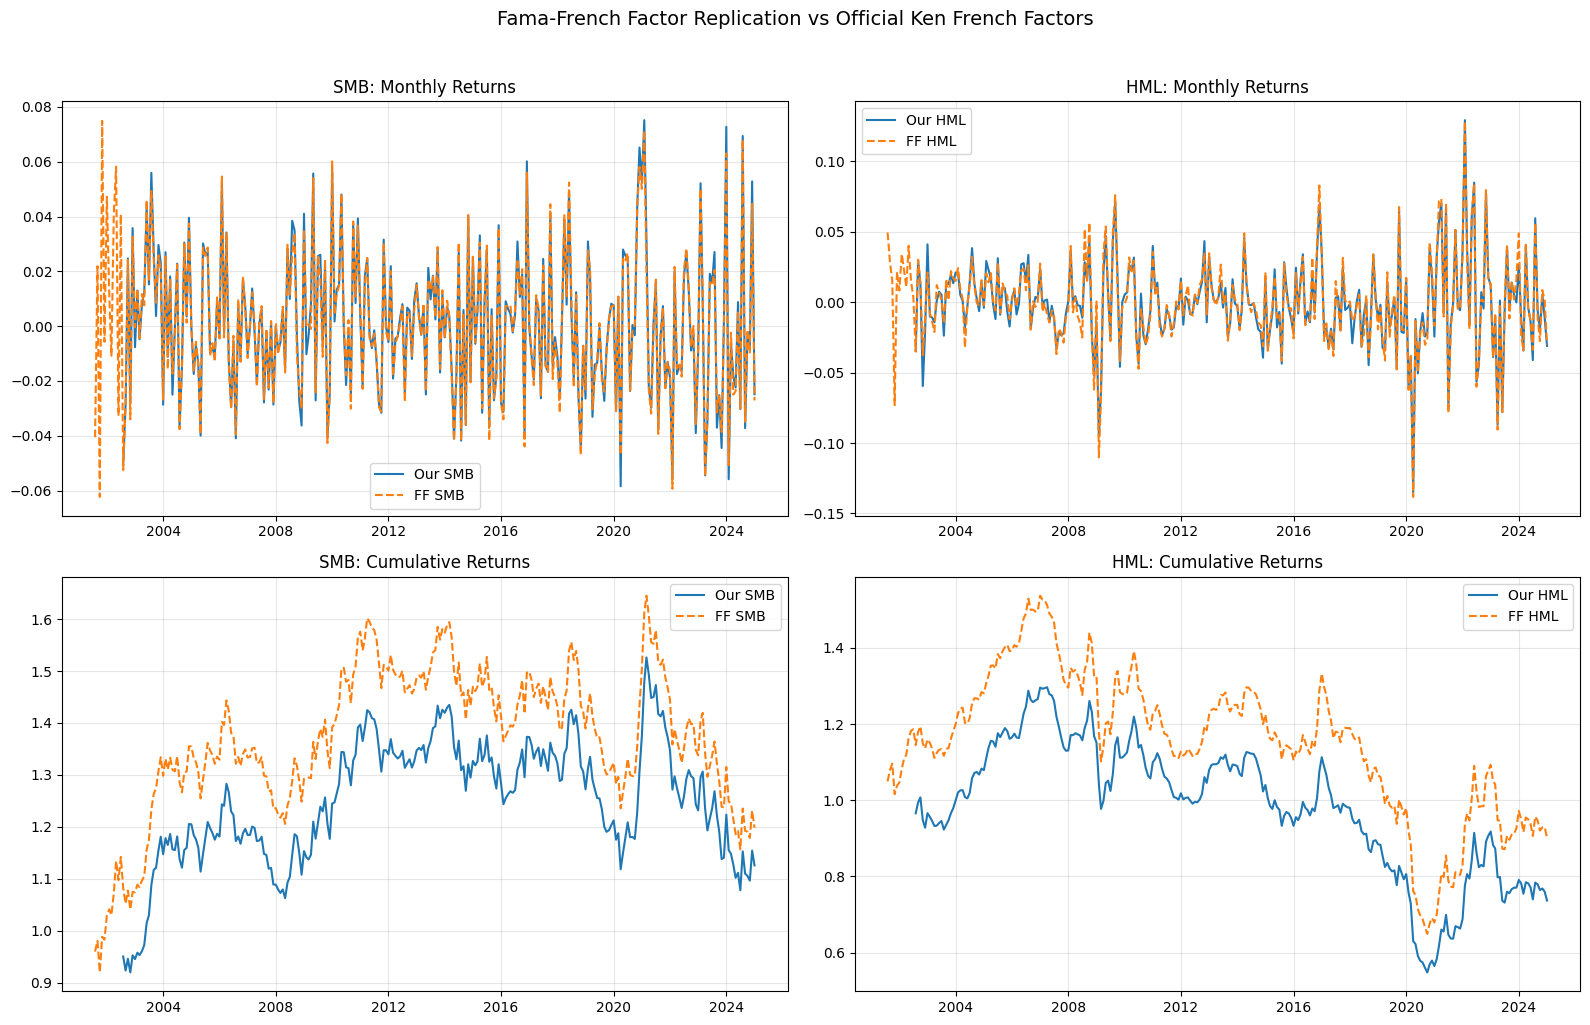

In [22]:
# ── Time series plots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# SMB time series
axes[0, 0].plot(ff_comp['date'], ff_comp['Our SMB'], label='Our SMB', linewidth=1.5)
axes[0, 0].plot(ff_comp['date'], ff_comp['FF SMB'], label='FF SMB', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('SMB: Monthly Returns', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# HML time series
axes[0, 1].plot(ff_comp['date'], ff_comp['Our HML'], label='Our HML', linewidth=1.5)
axes[0, 1].plot(ff_comp['date'], ff_comp['FF HML'], label='FF HML', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('HML: Monthly Returns', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# SMB cumulative
cum_smb = (1 + ff_comp[['Our SMB', 'FF SMB']]).cumprod()
axes[1, 0].plot(ff_comp['date'], cum_smb['Our SMB'], label='Our SMB', linewidth=1.5)
axes[1, 0].plot(ff_comp['date'], cum_smb['FF SMB'], label='FF SMB', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('SMB: Cumulative Returns', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# HML cumulative
cum_hml = (1 + ff_comp[['Our HML', 'FF HML']]).cumprod()
axes[1, 1].plot(ff_comp['date'], cum_hml['Our HML'], label='Our HML', linewidth=1.5)
axes[1, 1].plot(ff_comp['date'], cum_hml['FF HML'], label='FF HML', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('HML: Cumulative Returns', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

fig.suptitle('Fama-French Factor Replication vs Official Ken French Factors', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

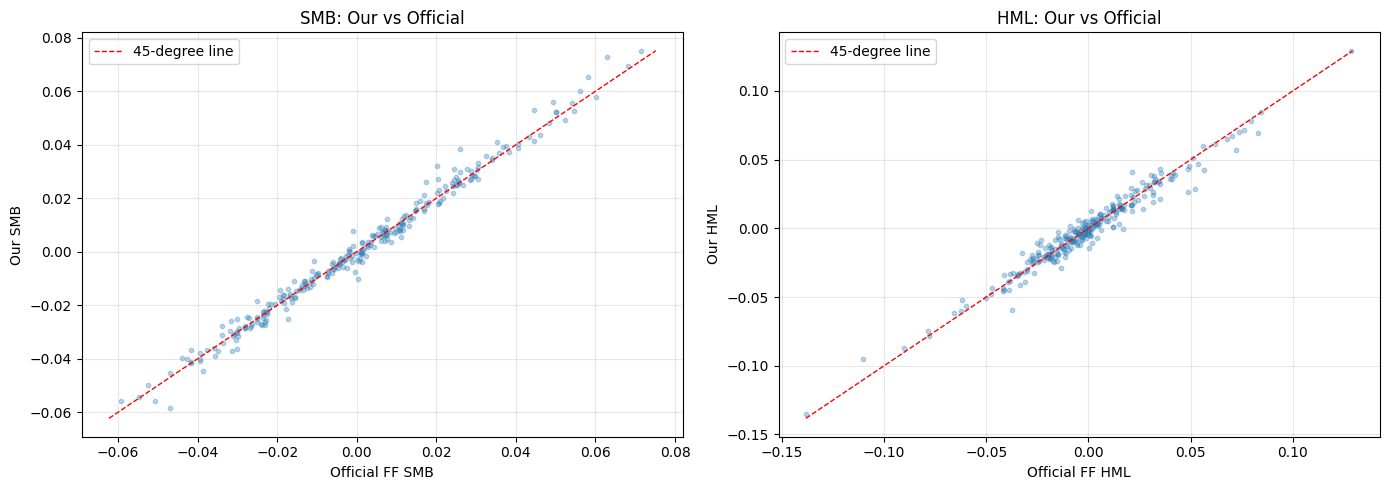

In [23]:
# ── Scatter plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (our, ff, name) in zip(axes, [
    ('Our SMB', 'FF SMB', 'SMB'),
    ('Our HML', 'FF HML', 'HML'),
]):
    ax.scatter(ff_comp[ff], ff_comp[our], alpha=0.3, s=10)
    # 45-degree line
    lims = [min(ff_comp[ff].min(), ff_comp[our].min()),
            max(ff_comp[ff].max(), ff_comp[our].max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='45-degree line')
    ax.set_xlabel(f'Official FF {name}')
    ax.set_ylabel(f'Our {name}')
    ax.set_title(f'{name}: Our vs Official', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Summary Statistics

In [24]:
# ── Summary statistics ───────────────────────────────────────────
summary_cols = ['Our SMB', 'FF SMB', 'Our HML', 'FF HML']
returns = ff_comp[summary_cols].copy()

summary = pd.DataFrame(columns=['Mean', 'Std Dev', 'Sharpe (monthly)', 'Min', 'Max'])
for col in summary_cols:
    r = returns[col].dropna()
    summary.loc[col] = [
        f'{r.mean():.4f}',
        f'{r.std():.4f}',
        f'{r.mean() / r.std():.4f}' if r.std() != 0 else 'N/A',
        f'{r.min():.4f}',
        f'{r.max():.4f}',
    ]

print('Monthly return summary statistics:')
display(summary)

Monthly return summary statistics:


,Mean,Std Dev,Sharpe (monthly),Min,Max
Our SMB,0.0008,0.0258,0.0298,-0.0584,0.0752
FF SMB,0.0010,0.0261,0.0375,-0.0623,0.0749
Our HML,-0.0007,0.0297,-0.0232,-0.1350,0.1293
FF HML,0.0001,0.0309,0.0036,-0.1383,0.1286


## 16. Conclusion

This notebook replicates the Fama-French SMB and HML factors from raw WRDS
data following the methodology of Fama and French (1993). Key design choices include:

- **June portfolio formation** to ensure accounting data availability
- **NYSE-only breakpoints** to avoid small-stock bias
- **December market equity** in the B/M denominator for proper timing
- **Preferred stock fallback hierarchy** for robust book equity
- **Delisting return adjustment** to avoid survivorship bias
- **Permco-level ME aggregation** for correct firm-level market cap
- **Value weighting** for economically meaningful portfolio returns

### Reference

Fama, E.F. and French, K.R. (1993), "Common Risk Factors in the Returns on
Stocks and Bonds", *Journal of Financial Economics*, 33(1), 3-56.